# S&P 500: data and features

Development-period Gaussian baseline following the [experiment plan](../docs/plans/sp500-real-data-experiments.md).
We audit the existing price-index file and prepare two separately named inputs:

- **Primary:** daily log return.
- **Secondary:** daily log return, trailing 60-day volatility, and trailing 20-day mean return.

The data are price-index observations, not dividend-inclusive returns. Total-return/proxy and aligned cash series remain future work; the trading section assumes zero cash returns.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Works when launched from the repository root or notebooks/.
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

from flexible_emission_hmm.feature import compute_features

DATA_PATH = project_root / "data/processed/sp500_index_price.csv"
VOLATILITY_DAYS = 60
MOMENTUM_DAYS = 20


## 1. Load and audit

Sort dates and check missing values and duplicate dates. The first stored return is expected to be missing because there is no preceding price. Calendar gaps include weekends and market holidays; the gap table is a check to inspect, not proof of missing trading observations. We do not fill dates or remove extreme returns.


In [2]:
raw = pd.read_csv(DATA_PATH, parse_dates=["YYYYMMDD"])
duplicate_dates = int(raw["YYYYMMDD"].duplicated().sum())
assert raw["YYYYMMDD"].notna().all(), "Missing dates need investigation."
assert duplicate_dates == 0, "Duplicate dates need investigation."

prices = raw.sort_values("YYYYMMDD").set_index("YYYYMMDD")
prices.index.name = "date"
assert prices["DlyPrcInd"].notna().all(), "Missing prices need investigation."
assert np.isfinite(prices["DlyPrcInd"]).all() and (prices["DlyPrcInd"] > 0).all()

simple_returns = prices["DlyPrcInd"].pct_change(fill_method=None)
return_error = (simple_returns - prices["DlyPrcRet"]).abs()
# Stored returns are rounded to six decimal places.
assert return_error.dropna().le(1e-6).all(), "Stored returns disagree with prices."
assert prices["DlyPrcRet"].iloc[1:].notna().all(), "Unexpected missing stored returns."

audit = pd.Series({
    "observations": len(prices),
    "first_date": prices.index.min().date(),
    "last_date": prices.index.max().date(),
    "duplicate_dates": duplicate_dates,
    "missing_prices": int(prices["DlyPrcInd"].isna().sum()),
    "missing_stored_returns": int(prices["DlyPrcRet"].isna().sum()),
    "max_absolute_return_error": return_error.max(),
}, name="data audit")
display(audit)
display(prices.head())

gaps = prices.index.to_series().diff().dt.days
# Show the longest gaps for manual inspection against the market calendar.
display(gaps.nlargest(5).rename("calendar_days_since_previous_observation").to_frame())


observations                      15982
first_date                   1962-07-02
last_date                    2025-12-31
duplicate_dates                       0
missing_prices                        0
missing_stored_returns                1
max_absolute_return_error      0.000001
Name: data audit, dtype: object

,DlyPrcInd,DlyPrcRet
date,,
1962-07-02,55.86,NaN
1962-07-03,56.49,0.011278
1962-07-05,56.81,0.005665
1962-07-06,56.17,-0.011266
1962-07-09,56.55,0.006765


,calendar_days_since_previous_observation
date,
2001-09-17,7.0
1968-07-08,5.0
2007-01-03,5.0
2012-10-31,5.0
1962-09-04,4.0


## 2. Build features

Use the repository's `compute_features` helper on the full chronological history so later windows can use earlier observations for warm-up. Rolling windows count observations and include the current day's return: these features are available **after that day's close**.

Returns are decimal log returns; volatility is daily sample standard deviation (not annualized). Keep recomputed simple returns separately for future portfolio accounting. Only incomplete warm-up rows are excluded from each feature configuration. No scaling is fitted here; any learned transformation must later be fitted on the training window only.


In [3]:
features = compute_features(
    prices["DlyPrcInd"],
    volatility_days=VOLATILITY_DAYS,
    momentum_days=MOMENTUM_DAYS,
)

data = prices.join(simple_returns.rename("simple_return")).join(features)
primary_features = features[["r_t"]].dropna()
secondary_features = features[["r_t", "sigma_t", "m_t"]].dropna()

feature_summary = pd.DataFrame([
    {"configuration": name, "rows": len(frame), "dimensions": frame.shape[1],
     "first_date": frame.index.min().date(), "last_date": frame.index.max().date()}
    for name, frame in [("primary", primary_features), ("secondary", secondary_features)]
]).set_index("configuration")
display(feature_summary)
display(secondary_features.head())


,rows,dimensions,first_date,last_date
configuration,,,,
primary,15981,1,1962-07-03,2025-12-31
secondary,15922,3,1962-09-26,2025-12-31


,r_t,sigma_t,m_t
date,,,
1962-09-26,-0.014323,0.007448,-0.002297
1962-09-27,-0.006791,0.007354,-0.002526
1962-09-28,0.008925,0.007411,-0.002097
1962-10-01,-0.013959,0.007485,-0.003168
1962-10-02,0.010933,0.007570,-0.002146


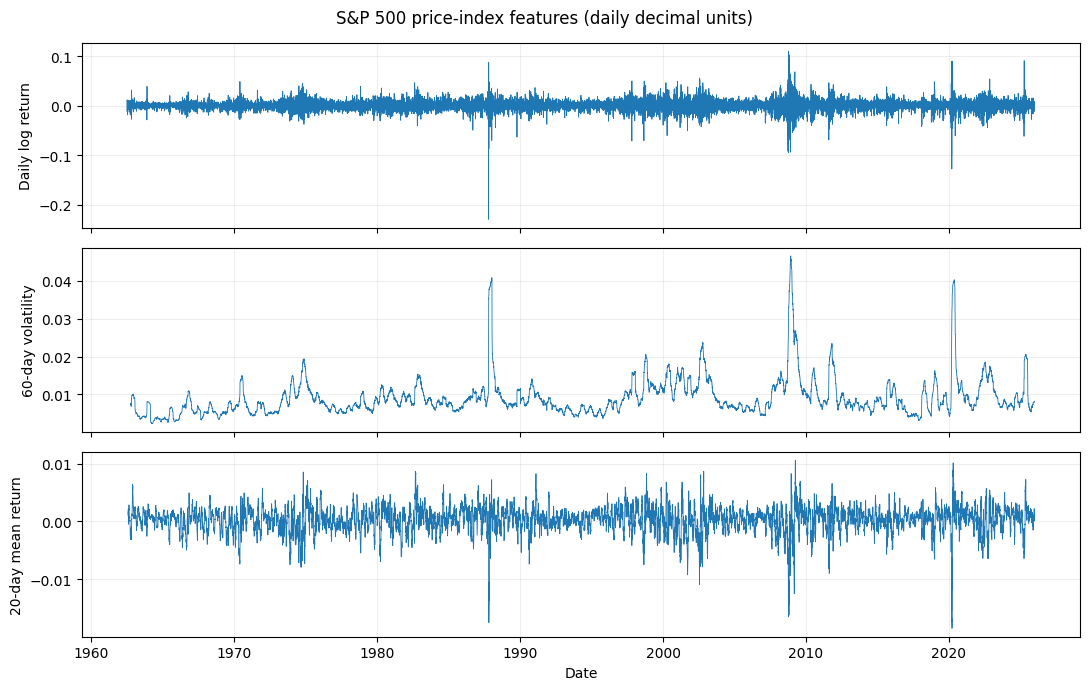

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, column, label in zip(
    axes,
    ["r_t", "sigma_t", "m_t"],
    ["Daily log return", f"{VOLATILITY_DAYS}-day volatility", f"{MOMENTUM_DAYS}-day mean return"],
):
    ax.plot(features.index, features[column], linewidth=0.6)
    ax.set_ylabel(label)
    ax.grid(alpha=0.2)
axes[-1].set_xlabel("Date")
fig.suptitle("S&P 500 price-index features (daily decimal units)")
fig.tight_layout()
plt.show()


`primary_features` and `secondary_features` are date-indexed inputs ready for later experiments. `data` retains prices, simple returns, and warm-up rows for inspection.

Rolling features overlap and may create apparent regime persistence. The two configurations have different dimensions, so their joint likelihoods should not be compared directly.


## 3. Chronological development specification and model fitting

The return-only Gaussian baseline evaluates 1990–2015, fitting the preceding ten years before each evaluation year. Ten deterministic starts are ranked by finite training likelihood. The 2016–2025 period is reserved for a frozen final evaluation.


In [5]:
from model_evaluation.real_data import walk_forward_gaussian, predictive_summary, backtest, portfolio_summary

FIRST_YEAR, LAST_YEAR = 1990, 2015
TRAINING_YEARS, N_STARTS, MASTER_SEED, MAX_ITER = 10, 10, 42, 300
experiment_data = data[["r_t", "simple_return", "sigma_t", "m_t"]].dropna()
forecasts, attempts, fitted_parameters = walk_forward_gaussian(
    experiment_data, FIRST_YEAR, LAST_YEAR, TRAINING_YEARS, N_STARTS, MASTER_SEED, MAX_ITER
)
display(attempts.groupby("year").agg(starts=("seed", "size"), converged=("converged", "sum"), best_likelihood=("likelihood", "max")))
display(fitted_parameters[["year", "selected_seed", "training_rows", "evaluation_rows"]])


,starts,converged,best_likelihood
year,,,
1990,10,10,8264.395397
1991,10,10,8279.566278
1992,10,10,8272.879075
1993,10,10,8427.241588
1994,10,10,8524.219856
1995,10,10,8580.330794
1996,10,10,8632.253065
1997,10,10,8718.559808
1998,10,10,8790.697174


,year,selected_seed,training_rows,evaluation_rows
0,1990,1236794712,2528,253
1,1991,1020444164,2528,253
2,1992,1497108663,2528,254
3,1993,3875509506,2529,253
4,1994,1230191418,2529,252
5,1995,1314834145,2528,252
6,1996,3765852443,2528,254
7,1997,1676455515,2529,253
8,1998,2980161032,2529,252
9,1999,1830235276,2528,252


## 4. Sequential forecasts and predictive evaluation

Forecasts are scored before observing each return. The filter starts from the training-end posterior. HMM, single-Gaussian, and EWMA densities use identical dates and decimal-return units.


,observations,hmm_mean_nll,gaussian_mean_nll,ewma_mean_nll,coverage_50,width_50,coverage_90,width_90,coverage_95,width_95,downside_exceedance_0.01,downside_exceedance_0.05
period,,,,,,,,,,,,
combined,6553,-3.246137,-3.027895,-3.252691,0.532886,0.012422,0.898062,0.033669,0.947200,0.041650,0.015718,0.058599
1990,253,-3.170668,-3.172566,-3.198006,0.454545,0.010629,0.885375,0.031891,0.936759,0.040504,0.019763,0.067194
1991,253,-3.316231,-3.258127,-3.239609,0.509881,0.010230,0.920949,0.030219,0.952569,0.038092,0.007905,0.027668
1992,254,-3.612395,-3.437717,-3.662844,0.625984,0.010074,0.980315,0.029513,0.996063,0.036931,0.000000,0.015748
1993,253,-3.724899,-3.500436,-3.793307,0.699605,0.009567,0.984190,0.028240,0.988142,0.035372,0.003953,0.007905
1994,252,-3.650552,-3.470766,-3.626588,0.599206,0.008984,0.944444,0.027172,0.984127,0.034542,0.003968,0.039683
1995,252,-3.803699,-3.544713,-3.871016,0.670635,0.008576,0.984127,0.026710,0.996032,0.033858,0.000000,0.011905
1996,254,-3.503476,-3.403253,-3.461308,0.496063,0.008237,0.913386,0.026717,0.960630,0.034094,0.011811,0.047244
1997,253,-3.100538,-3.031641,-3.033175,0.478261,0.012638,0.869565,0.034146,0.944664,0.042345,0.019763,0.067194


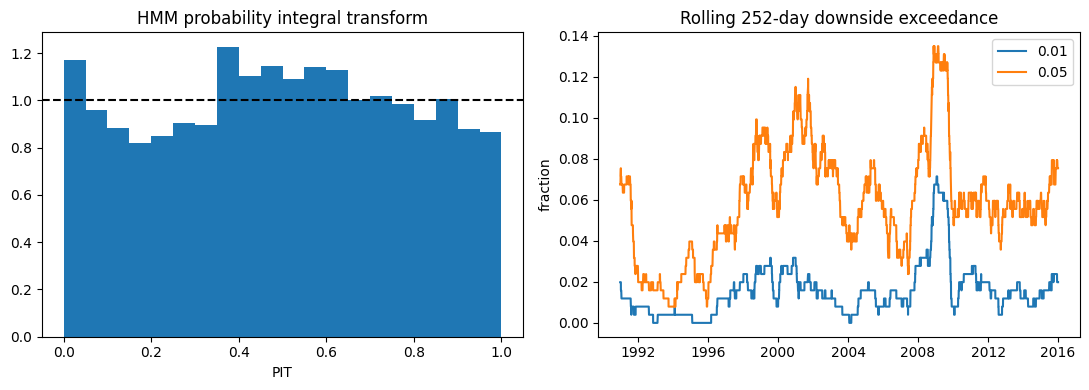

In [6]:
scores = predictive_summary(forecasts)
display(scores)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(forecasts.pit, bins=20, density=True)
axes[0].axhline(1, color="black", linestyle="--")
axes[0].set(title="HMM probability integral transform", xlabel="PIT")
for level in ("0.01", "0.05"):
    violations = forecasts.r_t.to_numpy() < np.array([item[level] for item in forecasts.quantiles])
    axes[1].plot(forecasts.index, pd.Series(violations.astype(float), index=forecasts.index).rolling(252).mean(), label=level)
axes[1].set(title="Rolling 252-day downside exceedance", ylabel="fraction")
axes[1].legend()
fig.tight_layout()
plt.show()


## 5. Regime interpretation and conditional performance

States are ordered by training-period emission volatility for reporting. Groups use predicted state probabilities before each return. External reference groups use lagged features.


In [7]:
volatility_order = {int(row.year): np.argsort(row.variances) for row in fitted_parameters.itertuples()}
forecasts["predicted_volatility_regime"] = [
    int(np.where(volatility_order[int(year)] == np.argmax(probabilities))[0][0])
    for year, probabilities in zip(forecasts.year, forecasts.predicted_state)
]
display(forecasts.groupby("predicted_volatility_regime").agg(observations=("r_t", "size"), mean_return=("r_t", "mean"), return_volatility=("r_t", "std"), mean_target_weight=("target_weight", "mean")))
display(forecasts.groupby("reference_group").agg(observations=("r_t", "size"), mean_return=("r_t", "mean")))


,observations,mean_return,return_volatility,mean_target_weight
predicted_volatility_regime,,,,
0,1790,0.000146,0.007039,0.882810
1,4155,0.000252,0.010539,0.619591
2,608,0.000733,0.022061,0.368396


,observations,mean_return
reference_group,,
high volatility / negative momentum,1421,0.000342
high volatility / positive momentum,1722,0.000125
low volatility / negative momentum,1102,0.000497
low volatility / positive momentum,2308,0.000219


## 6. Lagged trading comparison

A signal after close t executes at close t+1 and earns the return ending t+2. Turnover uses drifted holdings and continues across refits. Cash earns an assumed zero return; this price-index backtest is illustrative, not an investable total-return result.


In [8]:
trading, trading_rows = {}, []
strategies = {"hmm_vol_target": forecasts.target_weight, "ewma_vol_target": forecasts.ewma_target_weight, "buy_and_hold": pd.Series(1.0, index=forecasts.index), "fixed_60_percent": pd.Series(0.6, index=forecasts.index)}
for name, weights in strategies.items():
    comparison = forecasts.assign(strategy_weight=weights)
    for basis_points in (1, 5, 10):
        result = backtest(comparison, cash_return=0.0, cost_bps=basis_points, weight_column="strategy_weight")
        trading[(name, basis_points)] = result
        trading_rows.append({"strategy": name, "cost_bps": basis_points, **portfolio_summary(result.net_return, result.cash_return, result.turnover, result.strategy_weight)})
trading_summary = pd.DataFrame(trading_rows).set_index(["strategy", "cost_bps"])
display(trading_summary)


observations    sharpe      cagr  \
strategy         cost_bps                                     
hmm_vol_target   1                 6553  0.489406  0.043916   
                 5                 6553  0.463192  0.041248   
                 10                6553  0.430418  0.037924   
ewma_vol_target  1                 6553  0.548792  0.051427   
                 5                 6553  0.532352  0.049688   
                 10                6553  0.511799  0.047519   
buy_and_hold     1                 6553  0.464696  0.069817   
                 5                 6553  0.464613  0.069800   
                 10                6553  0.464509  0.069780   
fixed_60_percent 1                 6553  0.464267  0.045348   
                 5                 6553  0.462467  0.045144   
                 10                6553  0.460217  0.044889   

                           annual_volatility  max_drawdown  mean_turnover  \
strategy         cost_bps                                                   
hmm_vol_target   1                  0.097557     -0.352388       0.025381   
                 5                  0.097553     -0.358305       0.025381   
                 10                 0.097549     -0.365626       0.025380   
ewma_vol_target  1                  0.100624     -0.338109       0.016417   
                 5                  0.100622     -0.341334       0.016417   
                 10                 0.100620     -0.345344       0.016417   
buy_and_hold     1                  0.180217     -0.567754       0.000153   
                 5                  0.180216     -0.567754       0.000153   
                 10                 0.180214     -0.567754       0.000152   
fixed_60_percent 1                  0.108130     -0.380417       0.001936   
                 5                  0.108129     -0.380763       0.001936   
                 10                 0.108127     -0.381196       0.001936   

                           mean_exposure  
strategy         cost_bps                 
hmm_vol_target   1              0.668185  
                 5              0.668185  
                 10             0.668185  
ewma_vol_target  1              0.726761  
                 5              0.726761  
                 10             0.726761  
buy_and_hold     1              1.000000  
                 5              1.000000  
                 10             1.000000  
fixed_60_percent 1              0.600000  
                 5              0.600000  
                 10             0.600000

## 7. Uncertainty, sensitivity, and artifact export

Paired year blocks provide uncertainty for density-score differences. Five- and twenty-year windows, Student-t emissions, dividend-inclusive returns, and aligned cash remain later milestones. Each export uses a readable UTC timestamp folder and retains its reproducibility hash in the manifest. Leave 2016–2025 untouched. See [Gaussian-emission diagnostics](sp500_emission_diagnostics.ipynb) for distribution plots based on the saved artifacts.


In [9]:
yearly_differences = forecasts.groupby("year").apply(lambda group: pd.Series({"hmm_minus_gaussian_nll": (group.gaussian_log_density - group.hmm_log_density).mean(), "hmm_minus_ewma_nll": (group.ewma_log_density - group.hmm_log_density).mean()}), include_groups=False)
bootstrap_rng = np.random.default_rng(MASTER_SEED)
bootstrap_indices = bootstrap_rng.integers(0, len(yearly_differences), size=(2000, len(yearly_differences)))
bootstrap_means = yearly_differences.to_numpy()[bootstrap_indices].mean(axis=1)
uncertainty = pd.DataFrame({"estimate": yearly_differences.mean(), "lower_95": np.quantile(bootstrap_means, 0.025, axis=0), "upper_95": np.quantile(bootstrap_means, 0.975, axis=0)})
display(uncertainty)


,estimate,lower_95,upper_95
hmm_minus_gaussian_nll,-0.218192,-0.325633,-0.148296
hmm_minus_ewma_nll,0.006485,-0.014767,0.031232


In [11]:
import hashlib
import json
from datetime import datetime, timezone
settings = {"first_year": FIRST_YEAR, "last_year": LAST_YEAR, "training_years": TRAINING_YEARS, "n_starts": N_STARTS, "master_seed": MASTER_SEED, "max_iter": MAX_ITER, "cash_return_assumption": 0.0, "cost_bps": [1, 5, 10], "instrument": "S&P 500 price index"}
data_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
source_hash = hashlib.sha256((project_root / "src/model_evaluation/real_data.py").read_bytes()).hexdigest()
run_id = hashlib.sha256(json.dumps({"data_hash": data_hash, "source_hash": source_hash, "settings": settings}, sort_keys=True).encode()).hexdigest()[:16]
saved_at = datetime.now(timezone.utc)
timestamp = saved_at.strftime("%Y-%m-%d_%H-%M-%S_%f_UTC")
run_directory = project_root / "data/artifacts/sp500" / timestamp
run_directory.mkdir(parents=True, exist_ok=False)
manifest = {"run_id": run_id, "saved_at_utc": saved_at.isoformat(), "data_path": str(DATA_PATH.relative_to(project_root)), "data_sha256": data_hash, "source_sha256": source_hash, "settings": settings, "stage": "development", "final_period_used": False}
(run_directory / "manifest.json").write_text(json.dumps(manifest, indent=2))
forecasts.reset_index().to_json(run_directory / "forecasts.json", orient="records", date_format="iso", indent=2)
attempts.to_json(run_directory / "attempts.json", orient="records", indent=2)
fitted_parameters.to_json(run_directory / "parameters.json", orient="records", indent=2)
scores.to_csv(run_directory / "predictive_scores.csv")
trading_summary.to_csv(run_directory / "trading_summary.csv")
uncertainty.to_csv(run_directory / "uncertainty.csv")
trading[("hmm_vol_target", 5)].reset_index().to_json(run_directory / "date_level_backtest.json", orient="records", date_format="iso", indent=2)
print(f"Saved development run {run_id} to {run_directory}")


Saved development run cdf24bec574ed846 to /Users/yushe/Desktop/UNI/FALL26/CSCD94/FlexibleEmissionHMM/data/artifacts/sp500/2026-10-02_20-30-34_648329_UTC
